In [2]:
import sys # system functions (like exit)
from typing import List, Tuple, Mapping # type hints

import datasets # contains the NER dataset
from tqdm import tqdm # progress bars
import numpy as np
import matplotlib.pyplot as plt

import gensim.downloader as api # pretrained embedding

import torch # the main pytorch library
import torch.nn as nn # neural networks
import torch.optim as optim # optimizers
import torch.nn.functional as F # activation functions
from torch.nn.utils.rnn import pad_sequence # padding
from torch.utils.data import Dataset, DataLoader # data loading and processing

## Dataset

**[HuggingFace](https://huggingface.co/datasets/benjamin/ner-uk)** <br>
**[GitHub](https://github.com/lang-uk/ner-uk/tree/master)**

In [3]:
dataset = datasets.load_dataset("benjamin/ner-uk")  # load the dataset for Named Entity Recognition (NER) for Ukrainian
dataset  # show the dataset information

DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 10833
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 1307
    })
    test: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 668
    })
})

In [ ]:
# Get one sample
sample_1 = dataset["train"][0]
dc_1 = {key: value for key, value in sample_1.items() if key in ["tokens", "ner_tags"]}
dc_1

{'tokens': ['Зрозуміло',
  ',',
  'що',
  'український',
  'бізнес',
  'почав',
  'використовувати',
  'КСВ',
  'як',
  'інструмент',
  'формування',
  'своєї',
  'репутації',
  'буквально',
  'декілька',
  'років',
  'тому',
  '.'],
 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}

In [6]:
# Create a dictionary of unique words and assign an index to each of them
TOK_PAD_ID = 0

vocab = {"<PAD>": TOK_PAD_ID}  # dictionary of unique words
curr_idx = 1  # current index for the dictionary
for split in ("train", "validation", "test"):
    for sample in dataset[split]:
        for word in sample["tokens"]:
            if word not in vocab:
                vocab[word] = curr_idx
                curr_idx += 1

print("Vocab size:", len(vocab))  # show the number of unique words in the vocabulary

Vocab size: 50205


In [7]:
# Create a dictionary of unique NER tags
NER_PAD_ID = -100

targets = set()  # set of unique NER tags
for split in ("train", "validation", "test"):
    for sample in dataset[split]:
        targets.update(sample["ner_tags"])

targets = sorted(targets)  # sort the set of unique NER tags
print("Unique targets:", len(targets))
targets

Unique targets: 9


[0, 1, 2, 3, 4, 5, 6, 7, 8]

## PyTorch Datasets & DataLoaders

In [8]:
class NERDataset(Dataset):
    def __init__(self, samples: datasets.Dataset, vocabulary: Mapping[str, int]) -> None:
        self.samples = samples
        self.vocabulary = vocabulary

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> Tuple[torch.LongTensor, torch.LongTensor]:
        sample = self.samples[index]
        doc = torch.LongTensor([self.vocabulary[token] for token in sample["tokens"]])  # convert tokens to tensor
        label = torch.LongTensor(sample["ner_tags"])  # convert NER tags to tensor
        return doc, label  # return a tuple with tokens and NER tags

In [9]:
def seq_collate_fn(
    batch: List[Tuple[torch.LongTensor, torch.LongTensor]], data_pad: int, label_pad: int
) -> Tuple[torch.LongTensor, torch.LongTensor]:
    """Combine samples into batch that can be used laten by RNN model.

    Args:
        batch: list with tensors that should be packed into batch.
            Expected that each list sample will be a tuple of (text_tokens, label_tokens).
        data_pad: value to use for padding text tokens.
        label_pad: value to use for padding label tokens.

    Returns:
        Padded and packed into batch text tokens and padded and packed into batch label tokens.
    """
    token_ids = pad_sequence([item[0] for item in batch], batch_first=True, padding_value=data_pad)
    label_ids = pad_sequence([item[1] for item in batch], batch_first=True, padding_value=label_pad)
    return token_ids, label_ids


def ner_collate_fn(batch: List[Tuple[torch.LongTensor, torch.LongTensor]]) -> Tuple[torch.LongTensor, torch.LongTensor]:
    """Collator function for our NER dataset.

    Args:
        batch: list with tensors that should be packed into batch.
            Expected that each list sample will be a tuple of (text_tokens, label_tokens).

    Returns:
        Padded and packed into batch text tokens and padded and packed into batch label tokens.
    """
    return seq_collate_fn(batch, TOK_PAD_ID, NER_PAD_ID)

In [10]:
train_dataset = NERDataset(dataset["train"], vocab)  # training dataset
validation_dataset = NERDataset(dataset["validation"], vocab)  # validation dataset
test_dataset = NERDataset(dataset["test"], vocab)  # test dataset

len(train_dataset), len(validation_dataset), len(test_dataset)  # show the number of samples in the datasets

(10833, 1307, 668)

In [11]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, collate_fn=ner_collate_fn)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=ner_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=ner_collate_fn)

len(train_loader), len(validation_loader), len(test_loader)  # show the number of batches in the loaders

(169, 21, 11)

# Training & Evaluation

In [12]:
def sequence_f1(true_labels: np.array, predicted_labels: np.array) -> np.array:
    """F1 score for one sequence.

    Args:
        true_labels: ground truth labels.
        predicted_labels: model predictions.

    Returns:
        F1 scores for each class.
    """
    assert len(true_labels) == len(predicted_labels), "Mismatched length between true labels and predicted labels"

    scores = []  # list to store F1 scores for each class
    for _cls in targets:  # iterate over unique classes of NER tags
        # calculate the quantity of true positives, false positives, and false negatives for the current class
        true_positives = np.sum((true_labels == predicted_labels) & (true_labels == _cls))
        false_positives = np.sum((true_labels != predicted_labels) & (predicted_labels == _cls))
        false_negatives = np.sum((true_labels != predicted_labels) & (true_labels == _cls))

        # calculate precision, recall, and F1 score for the current class
        precision = 0.0
        if true_positives + false_positives > 0:
            precision = np.nan_to_num(true_positives / (true_positives + false_positives), nan=0.0)

        recall = 0.0
        if true_positives + false_negatives > 0:
            recall = np.nan_to_num(true_positives / (true_positives + false_negatives), nan=0.0)

        f1_score = 0.0
        if precision + recall > 0:
            f1_score = np.nan_to_num(2 * (precision * recall) / (precision + recall), nan=0.0)

        scores.append(f1_score)  # add F1 score to the list
    return np.array(scores)  # return F1 scores as a numpy array

In [13]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: str = "cpu",
    verbose: bool = True,
) -> Mapping[str, np.array]:
    """Train model one epoch.

    Args:
        model: model to train.
        loader: dataloader to use for training.
        criterion: loss function to optimize.
        optimizer: model training algorithm.
        device: device to use for training.
            Default is `"cpu"`.
        verbose: option to print training progress bar.
            Default is `True`.

    Returns:
        dict with training logs
    """
    model.train()  # set model to training mode

    losses = []  # list to store loss values
    scores = []  # list to store F1 scores

    # ініціалізація прогрес-бару
    with tqdm(total=len(loader), desc="training", file=sys.stdout, ncols=100, disable=not verbose) as progress:
        for x_batch, y_true in loader:
            x_batch = x_batch.to(device)
            y_true = y_true.to(device)

            optimizer.zero_grad()

            log_prob = model(x_batch)

            B, T = y_true.shape  # get batch size and sequence length
            loss = criterion(log_prob.view(B * T, -1), y_true.view(B * T))  # loss calculation

            loss.backward()  # backpropagation (calculate gradients)
            losses.append(loss.item())  # add loss value to the list

            # Get the NumPy array of predicted labels and ground truth labels
            y_pred = log_prob.argmax(2).detach().cpu().numpy()
            y_true = y_true.detach().cpu().numpy()

            # Calculate F1 score for each sequence in the batch
            padding_mask = y_true != NER_PAD_ID
            for i in range(x_batch.size(0)):
                scores.append(sequence_f1(y_true[i][padding_mask[i]], y_pred[i][padding_mask[i]]))

            # Update the progress bar
            progress.set_postfix_str(f"loss {losses[-1]:.4f}")

            optimizer.step()  # update model weights

            progress.update(1)

    logs = {
        "losses": np.array(losses),
        "f1": np.array(scores)
    }
    return logs  # return training logs as a dictionary

In [14]:
@torch.inference_mode()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: str = "cpu",
    verbose: bool = True,
) -> Mapping[str, np.array]:
    """Model evaluation.

    Args:
        model: model to evaluate.
        loader: dataloader to use for evaluation.
        criterion: loss function.
        device: device to use for evaluation.
            Default is `"cpu"`.
        verbose: option to print evaluation progress bar.
            Default is `True`.

    Returns:
        dict with evaluation logs
    """
    model.eval()

    losses = []
    scores = []

    # Progress bar initialization
    for x_batch, y_true in tqdm(loader, desc="evaluation", file=sys.stdout, ncols=100, disable=not verbose):
        x_batch = x_batch.to(device)
        y_true = y_true.to(device)

        log_prob = model(x_batch)

        B, T = y_true.shape  # get the batch size and sequence length
        loss = criterion(log_prob.view(B * T, -1), y_true.view(B * T))

        losses.append(loss.item())

        # Get the NumPy array of predicted labels and ground truth labels
        y_pred = log_prob.argmax(2).detach().cpu().numpy()
        y_true = y_true.detach().cpu().numpy()

        # Calculate F1 score for each sequence in the batch
        padding_mask = y_true != NER_PAD_ID
        for i in range(x_batch.size(0)):
            scores.append(sequence_f1(y_true[i][padding_mask[i]], y_pred[i][padding_mask[i]]))

    logs = {
        "losses": np.array(losses),
        "f1": np.array(scores)
    }
    return logs  # return evaluation logs as a dictionary

## Modeling

In [ ]:
class NER_RNN(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size, num_hidden_layers, num_classes):
        super(NER_RNN, self).__init__()
        # mapping from token_id to its vector representation
        self.embed = nn.Embedding(vocab_size, input_size, padding_idx=TOK_PAD_ID)
        # some RNN, could be nn.RNN, nn.LSTM, nn.GRU
        self.rnn = nn.GRU(
            input_size, hidden_size, num_hidden_layers, bidirectional=True, dropout=0.2, batch_first=True
        )
        # norm layer
        self.layer_norm = nn.LayerNorm(hidden_size * 2)   # * 2 because of `bidirectional=True`
        # classification head
        self.fc = nn.Linear(hidden_size * 2, num_classes)  # * 2 because of `bidirectional=True`

    def forward(self, x):
        x = self.embed(x)  # get embeddings for tokens
        x, _ = self.rnn(x)  # apply recurrent layer
        x = self.layer_norm(x)  # apply layer normalization
        x = F.relu(x)  # apply ReLU activation function
        x = self.fc(x)  # apply classification head
        scores = torch.log_softmax(x, dim=2)  # calculate logariphmic probabilities for each class
        return scores

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"  # define the device to use for training
print(f"Device - {device}")

torch.manual_seed(42)  # set random seed for reproducibility
model = NER_RNN(len(vocab), 512, 512, 3, len(targets))
model = model.to(device)
print(model)
# Define the number of trainable parameters
print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Device - cpu
NER_RNN(
  (embed): Embedding(50205, 512, padding_idx=0)
  (rnn): GRU(512, 512, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=1024, out_features=9, bias=True)
)
Number of trainable parameters - 38317577


In [ ]:
n_epochs = 15  # number of training epochs

train_losses = []
train_scores = []

valid_losses = []
valid_scores = []
best_score = float("-inf")  # variable to store the best validation score

# Training loop
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # train the model for one epoch and get training logs
    train_logs = train_one_epoch(model, train_loader, criterion, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["losses"]))
    train_scores.append(np.mean(train_logs["f1"], 0))
    print("      loss:", train_losses[-1])
    print("        f1:", train_scores[-1])

    # evaluate the model on the validation set and get validation logs
    valid_logs = evaluate(model, validation_loader, criterion, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["losses"]))
    valid_scores.append(np.mean(valid_logs["f1"], 0))
    print("      loss:", valid_losses[-1])
    print("        f1:", valid_scores[-1])

    # Save the model if the validation score is the best so far
    if valid_scores[-1].mean() >= best_score:
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": ep,
            "num_epochs": n_epochs,
            "metrics": {
                "training": {"loss": train_losses[-1], "accuracy": train_scores[-1]},
                "validation": {"loss": valid_losses[-1], "accuracy": valid_scores[-1]},
            },
        }
        torch.save(checkpoint, "best.pth")
        print("🟢 Saved new best state! 🟢")
        best_score = valid_scores[-1].mean()  # update the best validation score


Epoch  1/15
training: 100%|██████████████████████████████████████| 169/169 [49:42<00:00, 17.65s/it, loss 0.1843]
      loss: 0.28481438253405533
        f1: [9.72761771e-01 6.16370809e-05 1.54092702e-04 1.29437870e-04
 5.67301288e-04 1.29811428e-04 0.00000000e+00 0.00000000e+00
 3.46557509e-04]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:39<00:00,  1.89s/it]
      loss: 0.271463602603901
        f1: [9.74306938e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.56847743e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00
 3.06044376e-04]
🟢 Saved new best state! 🟢

Epoch  2/15
training: 100%|██████████████████████████████████████| 169/169 [46:48<00:00, 16.62s/it, loss 0.1467]
      loss: 0.20088335479328617
        f1: [9.81544802e-01 2.44090845e-03 9.47686503e-04 1.54092702e-04
 4.24425734e-03 1.98471400e-03 1.38683432e-04 3.21026463e-04
 3.23332932e-03]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:40<00:00,  1.93s/i

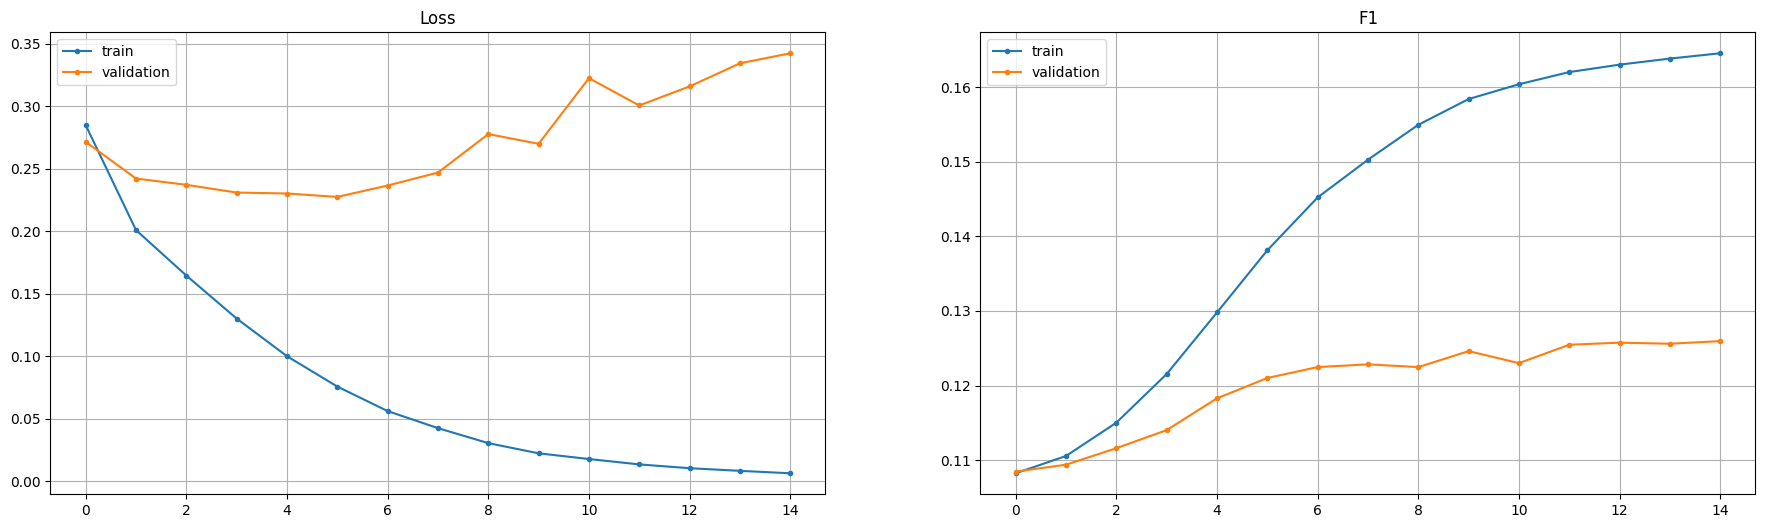

In [ ]:
# Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")
axes[0].legend(["train", "validation"])
axes[0].set_title("Loss")
axes[0].grid()

axes[1].plot(np.arange(len(train_scores)), [item.mean() for item in train_scores], ".-")
axes[1].plot(np.arange(len(valid_scores)), [item.mean() for item in valid_scores], ".-")
axes[1].legend(["train", "validation"])
axes[1].set_title("F1")
axes[1].grid()

In [ ]:
# Load the best model
model = NER_RNN(len(vocab), 512, 512, 3, len(targets))
model = model.to(device)

# Load the best model state
checkpoint = torch.load("best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print(f"Model loaded from the epoch {checkpoint['epoch'] + 1}/{checkpoint['num_epochs']}")

<ipython-input-19-cb95d313dfab>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best.pth", map_location=device)


Model loaded from the epoch 15/15


In [ ]:
# Evaluate the test set using the best model
test_logs = evaluate(model, test_loader, criterion, device, verbose=True)
print("Test loss:", np.mean(test_logs["losses"]))
print("Test F1:", np.mean(test_logs["f1"], axis=0))

evaluation: 100%|███████████████████████████████████████████████████| 11/11 [00:23<00:00,  2.14s/it]
Test loss: 0.3726474087346684
Test F1: [0.97712023 0.09395138 0.01277445 0.00998004 0.00491481 0.0255489
 0.00249501 0.00731038 0.00329341]


In [15]:
# Modofied class: dropout added, and GRU replaced with LSTM, pretrained embedding
class NER_RNN2(nn.Module):
    def __init__(self, vocab_size, input_size, hidden_size, num_hidden_layers, num_classes, vocab, embedding_trained=True, freeze=True):
        super(NER_RNN2, self).__init__()

        if embedding_trained:
            print("Loading pretrained embeddings...")
            self.embed = self.load_pretrained_embeddings(vocab, input_size, freeze)
        else:
            self.embed = nn.Embedding(vocab_size, input_size, padding_idx=TOK_PAD_ID) # Embedding layer

        self.embed_dropout = nn.Dropout(0.3) # Dropout layer
        self.rnn = nn.LSTM(input_size, hidden_size, num_hidden_layers, bidirectional=True, dropout=0.2, batch_first=True) # LSTM layer
        self.fc_res = nn.Linear(input_size, hidden_size * 2)  # Add a linear layer to x_res to match the size of x
        self.layer_norm = nn.LayerNorm(hidden_size * 2) # Layer normalization
        self.activation = nn.ReLU() # Activation function
        self.fc = nn.Linear(hidden_size * 2, num_classes) # Classification head

    def forward(self, x):
        x = self.embed(x) # Get embeddings for tokens
        x = self.embed_dropout(x) # Apply dropout
        x_res = x # Save the input to the residual connection
        x, _ = self.rnn(x) # Apply LSTM
        x_res = self.fc_res(x_res)  # Apply the linear layer to x_res
        assert x.shape == x_res.shape, f"Shapes do not match: {x.shape} and {x_res.shape}" # Check the shapes
        x = x + x_res # Add the residual connection
        x = self.layer_norm(x) # Apply layer normalization
        x = self.activation(x) # Apply ReLU activation function
        x = self.fc(x) # Apply classification head
        scores = torch.log_softmax(x, dim=2) # Calculate logariphmic probabilities for each class
        return scores # Return the scores

    def load_pretrained_embeddings(self, vocab, embedding_dim, freeze):
        # Load pretrained embeddings fastText
        ft = api.load("fasttext-wiki-news-subwords-300")

        # Create embedding matrix
        embedding_matrix = np.zeros((len(vocab), embedding_dim))
        unk_words = 0

        for word, idx in vocab.items():
            if word in ft:
                embedding_matrix[idx] = ft[word]
            else:
                unk_words += 1
                embedding_matrix[idx] = np.random.uniform(-0.1, 0.1, embedding_dim)  # Random vector for unknown words

        print(f"Unknown words: {unk_words} out of {len(vocab)}")

        # Initialize layer nn.Embedding with pretrained weights
        embedding_layer = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float), freeze=freeze) # freeze = True, will not train it in here to make it faster

        return embedding_layer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device - {device}")

torch.manual_seed(42)
# model = NER_RNN2(len(vocab), 512, 1024, 3, len(targets))  # Doubled hidden size
model = NER_RNN2(len(vocab), 300, 1024, 3, len(targets), vocab, embedding_trained=True, freeze=True)
model = model.to(device)
print(model)
print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.AdamW(model.parameters(), lr=1e-4) # AdamW optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # Learning rate scheduler: each 10 epochs decrease lr by 10%

Device - cuda
Loading pretrained embeddings...
[==================================================] 100.0% 958.5/958.4MB downloaded
Unknown words: 48815 out of 50205
NER_RNN2(
  (embed): Embedding(50205, 300)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (rnn): LSTM(300, 1024, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (fc_res): Linear(in_features=300, out_features=2048, bias=True)
  (layer_norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  (activation): ReLU()
  (fc): Linear(in_features=2048, out_features=9, bias=True)
)
Number of trainable parameters - 61865993


In [ ]:
n_epochs = 15

train_losses = []
train_scores = []

valid_losses = []
valid_scores = []

best_score = float("-inf")

# Training loop
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # Train the model for one epoch and get training logs
    train_logs = train_one_epoch(model, train_loader, criterion, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["losses"]))
    train_scores.append(np.mean(train_logs["f1"], 0))
    print("      loss:", train_losses[-1])
    print("        f1:", train_scores[-1])

    # Evaluate the model on the validation set and get validation logs
    valid_logs = evaluate(model, validation_loader, criterion, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["losses"]))
    valid_scores.append(np.mean(valid_logs["f1"], 0))
    print("      loss:", valid_losses[-1])
    print("        f1:", valid_scores[-1])

    scheduler.step() # update learning rate

    # Save the model if the validation score is the best so far
    if valid_scores[-1].mean() >= best_score:
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": ep,
            "num_epochs": n_epochs,
            "metrics": {
                "training": {"loss": train_losses[-1], "accuracy": train_scores[-1]},
                "validation": {"loss": valid_losses[-1], "accuracy": valid_scores[-1]},
            },
        }
        torch.save(checkpoint, "best.pth")
        print("🟢 Saved new best state! 🟢")
        best_score = valid_scores[-1].mean()


Epoch  1/15
training: 100%|██████████████████████████████████████| 169/169 [01:43<00:00,  1.63it/s, loss 0.3082]
      loss: 0.2947964647553376
        f1: [9.69464596e-01 6.16976611e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.08235285e-04]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.33it/s]
      loss: 0.2726672703311557
        f1: [9.73979097e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 8.16118337e-04]
🟢 Saved new best state! 🟢

Epoch  2/15
training: 100%|██████████████████████████████████████| 169/169 [01:59<00:00,  1.42it/s, loss 0.2633]
      loss: 0.2278335701519921
        f1: [9.80730683e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.59229126e-04 8.62919132e-04 0.00000000e+00 3.44874143e-04
 3.43900030e-04]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.20it/s

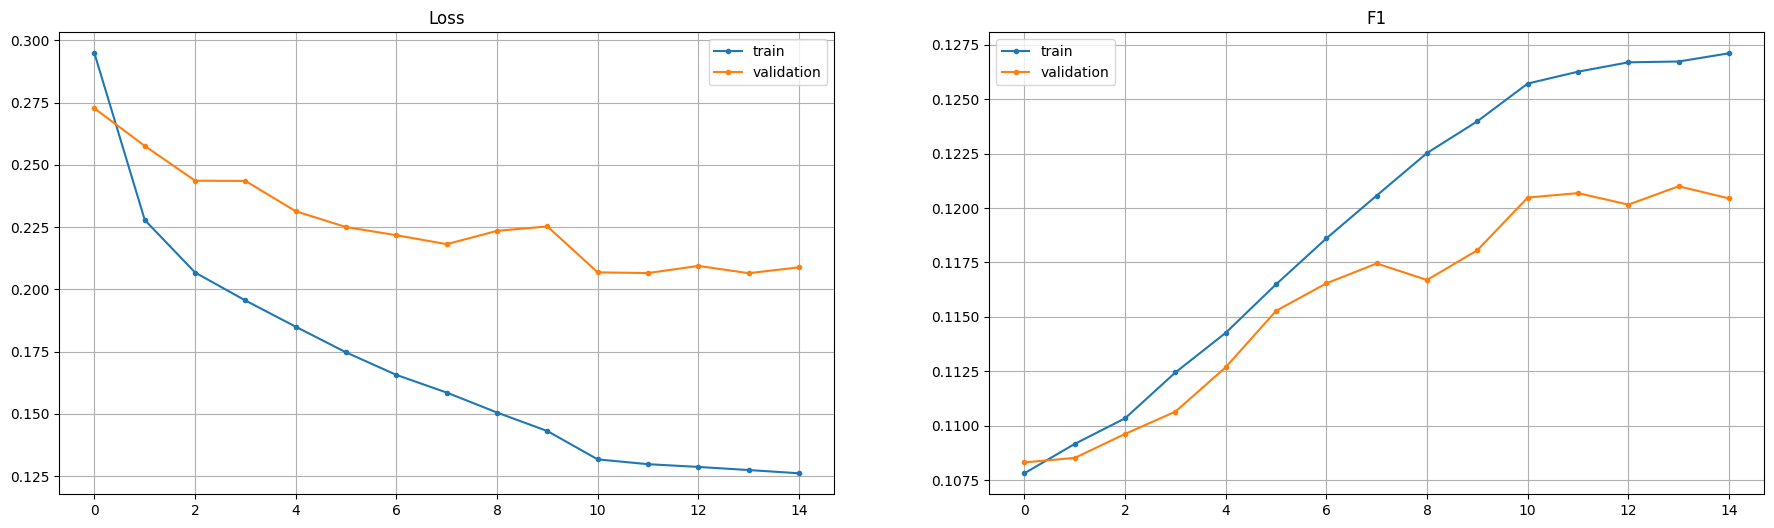

In [ ]:
# Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")
axes[0].legend(["train", "validation"])
axes[0].set_title("Loss")
axes[0].grid()

axes[1].plot(np.arange(len(train_scores)), [item.mean() for item in train_scores], ".-")
axes[1].plot(np.arange(len(valid_scores)), [item.mean() for item in valid_scores], ".-")
axes[1].legend(["train", "validation"])
axes[1].set_title("F1")
axes[1].grid()

In [ ]:
# Load the best model
model = NER_RNN2(len(vocab), 300, 1024, 3, len(targets), vocab, embedding_trained=True, freeze=True)
model = model.to(device)

# Load the best model state
checkpoint = torch.load("best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print(f"Model loaded from epoch {checkpoint['epoch'] + 1}/{checkpoint['num_epochs']}")

Loading pretrained embeddings...
Unknown words: 48815 out of 50205


<ipython-input-28-d76792ee5c18>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best.pth", map_location=device)


Model loaded from epoch 14/15


In [ ]:
# Evaluate the test set using the best model
test_logs = evaluate(model, test_loader, criterion, device, verbose=True)
print("Test loss:", np.mean(test_logs["losses"]))
print("Test F1:", np.mean(test_logs["f1"], axis=0))

evaluation: 100%|███████████████████████████████████████████████████| 11/11 [00:01<00:00,  5.87it/s]
Test loss: 0.1879537616941062
Test F1: [0.97827734 0.09235576 0.00936698 0.00349301 0.00176919 0.0213858
 0.000998   0.00511477 0.00424597]


In [16]:
# Freeze = False, will let the pretrained embedding to train

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device - {device}")

torch.manual_seed(42)
# model = NER_RNN2(len(vocab), 512, 1024, 3, len(targets))  # Doubled hidden size
model = NER_RNN2(len(vocab), 300, 1024, 3, len(targets), vocab, embedding_trained=True, freeze=False)
model = model.to(device)
print(model)
print("Number of trainable parameters -", sum(p.numel() for p in model.parameters() if p.requires_grad))

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = optim.AdamW(model.parameters(), lr=1e-4) # AdamW optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # Learning rate scheduler: each 10 epochs decrease lr by 10%

Device - cuda
Loading pretrained embeddings...
[==================================================] 100.0% 958.5/958.4MB downloaded
Unknown words: 48815 out of 50205
NER_RNN2(
  (embed): Embedding(50205, 300)
  (embed_dropout): Dropout(p=0.3, inplace=False)
  (rnn): LSTM(300, 1024, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True)
  (fc_res): Linear(in_features=300, out_features=2048, bias=True)
  (layer_norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
  (activation): ReLU()
  (fc): Linear(in_features=2048, out_features=9, bias=True)
)
Number of trainable parameters - 76927493


In [17]:
n_epochs = 15

train_losses = []
train_scores = []

valid_losses = []
valid_scores = []

best_score = float("-inf")

# Training loop
for ep in range(n_epochs):
    print(f"\nEpoch {ep + 1:2d}/{n_epochs:2d}")

    # Train the model for one epoch and get training logs
    train_logs = train_one_epoch(model, train_loader, criterion, optimizer, device, verbose=True)
    train_losses.append(np.mean(train_logs["losses"]))
    train_scores.append(np.mean(train_logs["f1"], 0))
    print("      loss:", train_losses[-1])
    print("        f1:", train_scores[-1])

    # Evaluate the model on the validation set and get validation logs
    valid_logs = evaluate(model, validation_loader, criterion, device, verbose=True)
    valid_losses.append(np.mean(valid_logs["losses"]))
    valid_scores.append(np.mean(valid_logs["f1"], 0))
    print("      loss:", valid_losses[-1])
    print("        f1:", valid_scores[-1])

    scheduler.step() # update learning rate

    # Save the model if the validation score is the best so far
    if valid_scores[-1].mean() >= best_score:
        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": ep,
            "num_epochs": n_epochs,
            "metrics": {
                "training": {"loss": train_losses[-1], "accuracy": train_scores[-1]},
                "validation": {"loss": valid_losses[-1], "accuracy": valid_scores[-1]},
            },
        }
        torch.save(checkpoint, "best.pth")
        print("🟢 Saved new best state! 🟢")
        best_score = valid_scores[-1].mean()


Epoch  1/15
training: 100%|██████████████████████████████████████| 169/169 [01:53<00:00,  1.48it/s, loss 0.2970]
      loss: 0.2917735655984935
        f1: [9.69513242e-01 4.32494880e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.95297971e-05
 2.26298962e-04]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.20it/s]
      loss: 0.2644486821123532
        f1: [9.74065425e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 5.10073961e-04
 1.25696797e-03]
🟢 Saved new best state! 🟢

Epoch  2/15
training: 100%|██████████████████████████████████████| 169/169 [02:04<00:00,  1.36it/s, loss 0.2322]
      loss: 0.20173914950980237
        f1: [9.81412454e-01 1.31064648e-02 3.73558066e-05 5.85552268e-04
 7.02565970e-04 6.84171598e-03 0.00000000e+00 6.16077299e-04
 3.34774490e-04]
evaluation: 100%|███████████████████████████████████████████████████| 21/21 [00:03<00:00,  6.07it/

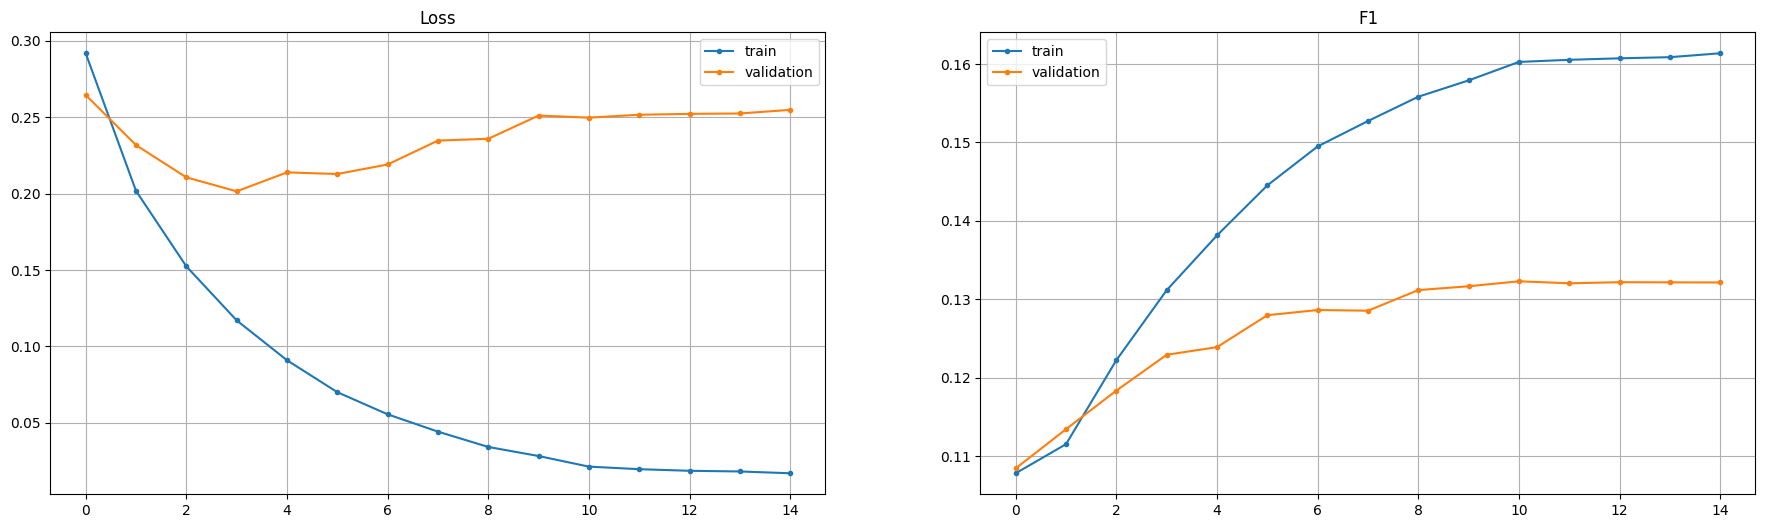

In [18]:
# Plot training and validation performance
fig, axes = plt.subplots(ncols=2, figsize=(22, 6))

axes[0].plot(np.arange(len(train_losses)), train_losses, ".-")
axes[0].plot(np.arange(len(valid_losses)), valid_losses, ".-")
axes[0].legend(["train", "validation"])
axes[0].set_title("Loss")
axes[0].grid()

axes[1].plot(np.arange(len(train_scores)), [item.mean() for item in train_scores], ".-")
axes[1].plot(np.arange(len(valid_scores)), [item.mean() for item in valid_scores], ".-")
axes[1].legend(["train", "validation"])
axes[1].set_title("F1")
axes[1].grid()

In [19]:
# Load the best model
model = NER_RNN2(len(vocab), 300, 1024, 3, len(targets), vocab, embedding_trained=True, freeze=False)
model = model.to(device)

# Load the best model state
checkpoint = torch.load("best.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print(f"Model loaded from epoch {checkpoint['epoch'] + 1}/{checkpoint['num_epochs']}")

Loading pretrained embeddings...
Unknown words: 48815 out of 50205


<ipython-input-19-a1c2be7ba687>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best.pth", map_location=device)


Model loaded from epoch 11/15


In [20]:
# Evaluate the test set using the best model
test_logs = evaluate(model, test_loader, criterion, device, verbose=True)
print("Test loss:", np.mean(test_logs["losses"]))
print("Test F1:", np.mean(test_logs["f1"], axis=0))

evaluation: 100%|███████████████████████████████████████████████████| 11/11 [00:02<00:00,  5.28it/s]
Test loss: 0.22747664898633957
Test F1: [0.9771792  0.15199942 0.02693185 0.01072854 0.0085163  0.04905902
 0.00449102 0.01405718 0.00696533]


**Analysis:**

**Model 1 (NER_RNN):**
Trained embeddings from scratch.  This means the embedding layer had to learn representations for all words in the vocabulary during training. This can be challenging, especially with limited data, and might contribute to the overfitting and poor performance on less frequent classes.

**Model 2 (NER_RNN2):**
Used pretrained embeddings with freeze=True. This means the embedding layer was initialized with representations learned from a large corpus (likely general-purpose text).  Critically, these pretrained weights were not updated during training.  The model leveraged existing knowledge about word relationships and semantics. This is a powerful technique, especially for tasks with limited labeled data.  Freezing the embeddings prevents the model from "unlearning" the valuable information already captured in the pretrained embeddings.  This explains why Model 2 generalizes so much better.

**Model 3 (NER_RNN2):**
Trained embeddings from scratch.  Similar to Model 1, the embedding layer had to learn representations from scratch.  Although Model 3 uses LSTMs and a similar architecture to Model 2, the lack of pretrained and frozen embeddings likely hindered its performance compared to Model 2. The higher number of parameters could have even worsened the performance because of the greater tendency to overfit.

**Key Differences and Implications:**

**Embedding Initialization:**
Model 2 started with a significant advantage due to pretrained embeddings. Models 1 and 3 had to learn embeddings from scratch, which is more difficult and data-intensive.

**Generalization:**
Model 2's frozen pretrained embeddings allowed it to generalize much better. The model didn't have to adjust the word representations, allowing it to focus on learning the task-specific relationships between words and labels.

**Training Data Efficiency:**
Model 2 was likely much more data-efficient. Pretrained embeddings provide a strong starting point, reducing the need for massive labeled datasets.

**Overfitting:**
Models 1 and 3 likely overfit more due to the need to learn embeddings from scratch with limited data.  Model 2 was less prone to overfitting because the pretrained embeddings already captured general language patterns.

**Conclusion:**

The success of Model 2 is primarily attributable to the use of pretrained and frozen embeddings. This highlights the importance of transfer learning for NLP tasks, especially when labeled data is scarce.  It's not just the LSTM architecture or residual connections; the pretrained embeddings are the dominant factor.  Model 3, despite being similar to Model 2 in architecture, shows that training embeddings from scratch can be a significant disadvantage.  Model 1 is the weakest due to the GRU architecture and the lack of pretraining.